# Jagran Lakecity University
## Faculty of Science and Technology
### BTech CSE

---

## Practical Record: Assignment 2 - Module 2
### **Practical 1: Basic Working of an Artificial Neuron**

| Academic Details | Information |
| :--- | :--- |
| **Course** | Soft Computing |
| **Module** | Module II: Fuzzy Logic and Systems |
| **Student Name** | *Aakash Sarang* |
| **Enrollment No.** | *2023BTCSE001* |
| **Academic Session** | 2026 – 2027 |

---

### 1. Aim
To understand and implement the basic working of an artificial neuron using Python.

### 2. Theory: What is an Artificial Neuron and How Does It Work?

An artificial neuron is the fundamental building block of an artificial neural network. It receives input signals, weights them according to their importance, combines them with a bias, and passes the result through an activation function to generate an output.

#### 1. The Core Components of an Artificial Neuron:
1. **Inputs ($x_1, x_2, \dots, x_n$):** The incoming numerical data or features.
2. **Weights ($w_1, w_2, \dots, w_n$):** Values that determine the strength and influence of each input. Positive weights excite (increase) the signal, while negative weights inhibit (decrease) the signal.
3. **Bias ($b$):** A constant number added to the sum. It shifts the activation threshold, allowing the neuron to fire even when inputs are zero.
4. **Weighted Sum ($z$):** The linear combination of all inputs multiplied by their respective weights, plus the bias:
   $$z = \sum_{i=1}^n w_i x_i + b = (w_1 x_1 + w_2 x_2 + \dots + w_n x_n) + b$$
5. **Activation Function ($f(z)$):** Decides whether the neuron should fire (activate) based on the weighted sum $z$. A classic threshold/step activation function is:
   $$y = f(z) = \begin{cases} 1 & \text{if } z \ge 0 \\ 0 & \text{if } z < 0 \end{cases}$$
6. **Output ($y$):** The final decision or activated signal produced by the neuron.

### 3. Step 1: Implementing the Artificial Neuron Class in Python

#### What this cell does:
In this code cell, we define an `ArtificialNeuron` class from scratch using Python and NumPy.
- The `__init__` method stores the neuron's weights and bias.
- The `weighted_sum(inputs)` method calculates $z = \mathbf{w} \cdot \mathbf{x} + b$.
- The `activate(z)` method applies the threshold step function ($1$ if $z \ge 0$, else $0$).
- The `forward(inputs)` method runs the complete end-to-end forward pass of the neuron and returns both the output $y$ and the net input $z$.

#### Formulas used:
$$z = \sum_{i=1}^n w_i x_i + b = \mathbf{w} \cdot \mathbf{x} + b$$
$$y = f(z) = \begin{cases} 1 & \text{if } z \ge 0 \\ 0 & \text{if } z < 0 \end{cases}$$
- $\mathbf{x} = [x_1, x_2, \dots, x_n]$: Input feature vector.
- $\mathbf{w} = [w_1, w_2, \dots, w_n]$: Weight vector.
- $b$: Scalar bias term.
- $z$: Net weighted input (scalar).
- $y$: Activated neuron output ($0$ or $1$).

In [1]:
import numpy as np

class ArtificialNeuron:
    def __init__(self, weights, bias):
        """
        Initialize the artificial neuron with weights and bias.
        """
        self.weights = np.array(weights, dtype=float)
        self.bias = float(bias)
    
    def calculate_weighted_sum(self, inputs):
        """
        Compute linear combination: z = w1*x1 + w2*x2 + ... + wn*xn + b
        """
        inputs = np.array(inputs, dtype=float)
        z = np.dot(inputs, self.weights) + self.bias
        return z
    
    def step_activation(self, z):
        """
        Step activation function: returns 1 if z >= 0, else 0.
        """
        return 1 if z >= 0.0 else 0
    
    def forward(self, inputs):
        """
        Perform forward pass: compute weighted sum and apply activation.
        """
        z = self.calculate_weighted_sum(inputs)
        y = self.step_activation(z)
        return y, z

print("ArtificialNeuron class created successfully.")

ArtificialNeuron class created successfully.


### 4. Step 2: Testing the Neuron with Sample Input Vectors

#### What this cell does:
In this code cell, we instantiate our artificial neuron with two weights ($w_1 = 1.5, w_2 = -0.8$) and a bias ($b = -0.5$).
We then pass several different 2D input samples through the neuron to observe how different values of $x_1$ and $x_2$ produce positive or negative weighted sums $z$, leading to activation ($y = 1$) or non-activation ($y = 0$).

#### Formulas used:
$$z = (1.5 	imes x_1) + (-0.8 	imes x_2) - 0.5$$
$$y = \begin{cases} 1 & \text{if } z \ge 0 \\ 0 & \text{if } z < 0 \end{cases}$$

In [2]:
# Define weights and bias for a 2-input artificial neuron
weights = [1.5, -0.8]
bias = -0.5
neuron = ArtificialNeuron(weights=weights, bias=bias)

# Define diverse test samples
test_samples = [
    [0.0, 0.0],
    [1.0, 0.0],
    [0.0, 1.0],
    [1.0, 1.0],
    [2.0, 1.0],
    [-1.0, 0.5],
    [0.5, -1.0]
]

print("=" * 70)
print("             ARTIFICIAL NEURON FORWARD INFERENCE TEST")
print(f"Neuron Configuration: Weights (w) = {weights}, Bias (b) = {bias}")
print("=" * 70)
print(f"{'Sample #':<10} | {'Inputs [x1, x2]':<18} | {'Weighted Sum z':<16} | {'Neuron Output y':<15}")
print("-" * 70)

for i, x in enumerate(test_samples, start=1):
    output, z = neuron.forward(x)
    status = "Active (Fired)" if output == 1 else "Inactive (Quiet)"
    print(f"Sample {i:<3} | [{x[0]:>4.1f}, {x[1]:>4.1f}]       | {z:>8.2f}         | {output} ({status})")

print("=" * 70)

             ARTIFICIAL NEURON FORWARD INFERENCE TEST
Neuron Configuration: Weights (w) = [1.5, -0.8], Bias (b) = -0.5
Sample #   | Inputs [x1, x2]    | Weighted Sum z   | Neuron Output y
----------------------------------------------------------------------
Sample 1   | [ 0.0,  0.0]       |    -0.50         | 0 (Inactive (Quiet))
Sample 2   | [ 1.0,  0.0]       |     1.00         | 1 (Active (Fired))
Sample 3   | [ 0.0,  1.0]       |    -1.30         | 0 (Inactive (Quiet))
Sample 4   | [ 1.0,  1.0]       |     0.20         | 1 (Active (Fired))
Sample 5   | [ 2.0,  1.0]       |     1.70         | 1 (Active (Fired))
Sample 6   | [-1.0,  0.5]       |    -2.40         | 0 (Inactive (Quiet))
Sample 7   | [ 0.5, -1.0]       |     1.05         | 1 (Active (Fired))


### 5. Step 3: Visualizing the Neuron's Decision Boundary and Activation Regions

#### What this cell does:
In this code cell, we visualize how an artificial neuron separates the input space.
The boundary where the neuron changes from inactive ($0$) to active ($1$) occurs where the net weighted sum is zero ($z = 0$).
We plot:
1. The decision boundary line $w_1 x_1 + w_2 x_2 + b = 0$.
2. The active region ($y = 1$) shaded in green, and inactive region ($y = 0$) shaded in red.
3. The sample test points evaluated in the previous step.

#### Formula for the Decision Boundary:
$$w_1 x_1 + w_2 x_2 + b = 0 \implies x_2 = -\left(\frac{w_1}{w_2}\right)x_1 - \frac{b}{w_2}$$
With $w_1 = 1.5, w_2 = -0.8, b = -0.5$:
$$x_2 = -\left(\frac{1.5}{-0.8}\right)x_1 - \frac{-0.5}{-0.8} = 1.875 x_1 - 0.625$$

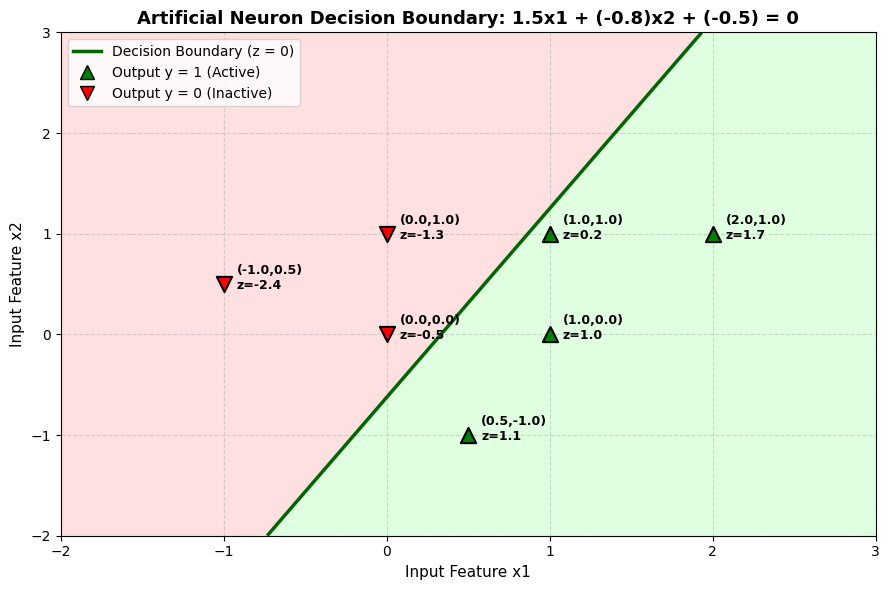

In [3]:
import matplotlib.pyplot as plt

# Generate a grid of points to visualize the decision boundary
x1_range = np.linspace(-2.0, 3.0, 300)
x2_range = np.linspace(-2.0, 3.0, 300)
X1, X2 = np.meshgrid(x1_range, x2_range)

# Compute weighted sum across the whole 2D grid
Z = (weights[0] * X1) + (weights[1] * X2) + bias
Y = (Z >= 0).astype(int)

plt.figure(figsize=(9, 6))

# Plot active (1) and inactive (0) regions
plt.contourf(X1, X2, Y, levels=[-0.5, 0.5, 1.5], colors=['#ffcccc', '#ccffcc'], alpha=0.6)
# Plot the exact dividing line where z = 0
plt.contour(X1, X2, Z, levels=[0], colors=['#006600'], linewidths=2.5)

# Plot test sample points
for x in test_samples:
    out, z_val = neuron.forward(x)
    color = 'green' if out == 1 else 'red'
    marker = '^' if out == 1 else 'v'
    plt.scatter(x[0], x[1], color=color, s=120, edgecolors='black', linewidth=1.5, marker=marker, zorder=5)
    plt.annotate(f"({x[0]},{x[1]})\nz={z_val:.1f}", (x[0]+0.08, x[1]-0.05), fontsize=9, weight='bold')

plt.title(f"Artificial Neuron Decision Boundary: {weights[0]}x1 + ({weights[1]})x2 + ({bias}) = 0", fontsize=13, weight='bold')
plt.xlabel("Input Feature x1", fontsize=11)
plt.ylabel("Input Feature x2", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

# Custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='#006600', lw=2.5, label='Decision Boundary (z = 0)'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='green', markeredgecolor='k', markersize=10, label='Output y = 1 (Active)'),
    Line2D([0], [0], marker='v', color='w', markerfacecolor='red', markeredgecolor='k', markersize=10, label='Output y = 0 (Inactive)')
]
plt.legend(handles=legend_elements, loc='upper left', fontsize=10)
plt.xlim(-2.0, 3.0)
plt.ylim(-2.0, 3.0)
plt.tight_layout()
plt.show()

### 6. Results and Key Observations

| Sample # | Input Vector ($x_1, x_2$) | Weighted Sum ($z = \mathbf{w} \cdot \mathbf{x} + b$) | Activation Condition | Neuron Output ($y$) | Neuron State |
| :---: | :---: | :---: | :---: | :---: | :---: |
| **Sample 1** | $[0.0, 0.0]$ | $-0.50$ | $z < 0$ | **0** | Inactive |
| **Sample 2** | $[1.0, 0.0]$ | $+1.00$ | $z \ge 0$ | **1** | Active |
| **Sample 3** | $[0.0, 1.0]$ | $-1.30$ | $z < 0$ | **0** | Inactive |
| **Sample 4** | $[1.0, 1.0]$ | $+0.20$ | $z \ge 0$ | **1** | Active |
| **Sample 5** | $[2.0, 1.0]$ | $+1.70$ | $z \ge 0$ | **1** | Active |
| **Sample 6** | $[-1.0, 0.5]$ | $-2.40$ | $z < 0$ | **0** | Inactive |
| **Sample 7** | $[0.5, -1.0]$ | $+1.05$ | $z \ge 0$ | **1** | Active |

#### Key Observations in Simple Words:
1. **The Role of Weights:**
   - Input $x_1$ has a positive weight ($+1.5$), so higher values of $x_1$ push the neuron towards firing ($y = 1$).
   - Input $x_2$ has a negative weight ($-0.8$), so higher values of $x_2$ inhibit the neuron and push it towards remaining inactive ($y = 0$).
2. **The Role of Bias:**
   - With bias $b = -0.5$, when both inputs are zero $(0, 0)$, the weighted sum is $z = -0.5$, which keeps the neuron inactive.
   - The bias shifts the boundary so the neuron requires a minimum positive contribution from the inputs before it can activate.
3. **Linear Separation:**
   - The decision boundary is a straight line ($1.5 x_1 - 0.8 x_2 - 0.5 = 0$).
   - The neuron cleanly divides the 2D input plane into two distinct regions: active ($y=1$) and inactive ($y=0$).

---
### 7. Conclusion
1. We successfully implemented the basic working of an artificial neuron in Python from scratch.
2. We verified how the neuron computes the linear weighted sum of inputs and applies a step activation function.
3. We observed and plotted the linear decision boundary that partitions the input space into active and inactive regions.